![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de modelos Bagging, Random Forest y XGBoost

En este taller podrán poner en práctica sus conocimientos sobre la construcción e implementación de modelos de Bagging, Random Forest y XGBoost. El taller está constituido por 8 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción precio de automóviles

En este taller se usará el conjunto de datos de Car Listings de Kaggle donde cada observación representa el precio de un automóvil teniendo en cuenta distintas variables como año, marca, modelo, entre otras. El objetivo es predecir el precio del automóvil. Para más detalles puede visitar el siguiente enlace: [datos](https://www.kaggle.com/jpayne/852k-used-car-listings).

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Importación de librerías
%matplotlib inline
import pandas as pd

# Lectura de la información de archivo .csv
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/dataTrain_carListings.zip')

# Preprocesamiento de datos para el taller
data = data.loc[data['Model'].str.contains('Camry')].drop(['Make', 'State'], axis=1)
data = data.join(pd.get_dummies(data['Model'], prefix='M', dtype=int))
data = data.drop(['Model'], axis=1)

# Visualización dataset
data.head()

,Price,Year,Mileage,M_Camry,M_Camry4dr,M_CamryBase,M_CamryL,M_CamryLE,M_CamrySE,M_CamryXLE
7,21995,2014,6480,0,0,0,1,0,0,0
11,13995,2014,39972,0,0,0,0,1,0,0
167,17941,2016,18989,0,0,0,0,0,1,0
225,12493,2014,51330,0,0,0,1,0,0,0
270,7994,2007,116065,0,1,0,0,0,0,0


In [5]:
display(Markdown(f"""### Datos iniciales:
                 \n Los datos cargados originalmente se componen de {data.shape[0]} filas, cada una representa una observación y {data.shape[1]} columnas, cada columna representa una variable."""))

# Análisis Valores Nulos\n
display(Markdown(f""" ### Análisis Valores Nulos:
    \n El dataset resultante tiene {data.isnull().sum().sum()} valores nulos."""))

### Datos iniciales:
                 
 Los datos cargados originalmente se componen de 10495 filas, cada una representa una observación y 10 columnas, cada columna representa una variable.

 ### Análisis Valores Nulos:
    
 El dataset resultante tiene 0 valores nulos.

In [7]:
# Separación de variables predictoras (X) y variable de interés (y)
y = data['Price']
X = data.drop(['Price'], axis=1)

In [8]:
# Separación de datos en set de entrenamiento y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [26]:
# Librerias adicionales
import numpy as np
from sklearn import metrics
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from IPython.display import Markdown, display
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor

### Punto 1 - Árbol de decisión manual

En la celda 1 creen un árbol de decisión **manualmente**  que considere los set de entrenamiento y test definidos anteriormente y presenten el RMSE y MAE del modelo en el set de test.

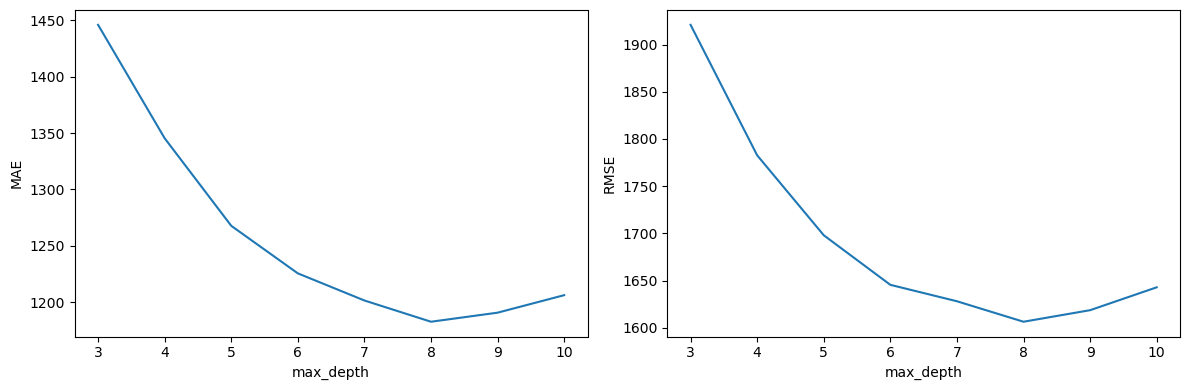

Mejor profundidad encontrada: 8
Métricas en ese punto -> RMSE: 1606.30, MAE: 1182.83


In [41]:
# Celda 1

# Definición de la función que calcula el mse
def mse(y):
    if y.shape[0] == 0:
        return 0
    else:
        return y.var()
    
# Definición de la función mse para calular la ganancia de una variable predictora j dado el punto de corte k
def mse_impurity(X_col, y, split):
    
    filter_l = X_col < split
    y_l = y.loc[filter_l]
    y_r = y.loc[~filter_l]
    
    n_l = y_l.shape[0]
    n_r = y_r.shape[0]
    
    mse_y = mse(y)
    mse_l = mse(y_l)
    mse_r = mse(y_r)
    
    gain = mse_y - (n_l / (n_l + n_r) * mse_l + n_r / (n_l + n_r) * mse_r)
    
    return gain

# Definición de la función best_split para calcular cuál es la mejor variable y punto de cortepara hacer la bifurcación del árbol
def best_split(X, y, num_pct=10):
    features = range(X.shape[1])
    best_split = [0, 0, 0]  # j, split, gain
    
    # Para todas las varibles 
    for j in features:
        
        splits = np.percentile(X.iloc[:, j], np.arange(0, 100, 100.0 / (num_pct+1)).tolist())
        splits = np.unique(splits)[1:]
        
        # Para cada partición
        for split in splits:
            gain = mse_impurity(X.iloc[:, j], y, split)
                        
            if gain > best_split[2]:
                best_split = [j, split, gain]
    
    return best_split

# Definición de la función tree_grow para hacer un crecimiento recursivo del árbol
def tree_grow(X, y, level=0, min_gain=0.001, max_depth=None, num_pct=10):
    
    # Si solo es una observación
    if X.shape[0] == 1:
        return dict(y_pred=y.iloc[:1].values[0], y_prob=0.5, level=level, split=-1, n_samples=1, gain=0)
    
    # Calcular la mejor división
    j, split, gain = best_split(X, y, num_pct)
    
    # Guardar el árbol y estimar la predicción
    y_pred = y.mean() 
    
    tree = dict(y_pred=y_pred, level=level, split=-1, n_samples=X.shape[0], gain=gain)
    # Revisar el criterio de parada 
    if gain < min_gain:
        return tree
    if max_depth is not None:
        if level >= max_depth:
            return tree   
    
    # Continuar creando la partición
    filter_l = X.iloc[:, j] < split
    X_l, y_l = X.loc[filter_l], y.loc[filter_l]
    X_r, y_r = X.loc[~filter_l], y.loc[~filter_l]
    tree['split'] = [j, split]

    # Siguiente iteración para cada partición
    
    tree['sl'] = tree_grow(X_l, y_l, level + 1, min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)
    tree['sr'] = tree_grow(X_r, y_r, level + 1, min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)
    
    return tree

# Definición de la función tree_predict para hacer predicciones según las variables 'X' y el árbol 'tree'
def tree_predict(X, tree):
    predicted = np.ones(X.shape[0])

    # Revisar si es el nodo final
    if tree['split'] == -1:
        predicted = predicted * tree['y_pred']
    else:
        
        j, split = tree['split']
        filter_l = (X.iloc[:, j] < split)
        X_l = X.loc[filter_l]
        X_r = X.loc[~filter_l]

        if X_l.shape[0] == 0:  # Si el nodo izquierdo está vacio solo continua con el derecho 
            predicted[~filter_l] = tree_predict(X_r, tree['sr'])
        elif X_r.shape[0] == 0:  #  Si el nodo derecho está vacio solo continua con el izquierdo
            predicted[filter_l] = tree_predict(X_l, tree['sl'])
        else:
            predicted[filter_l] = tree_predict(X_l, tree['sl'])
            predicted[~filter_l] = tree_predict(X_r, tree['sr'])

    return predicted


display(Markdown(f"""  """))

# Creación de lista de valores para iterar sobre diferentes valores de max_depth
estimator_range = range(3, 11, 1)

# Definición de lista para almacenar las métrcias (MAE y RMSE) para cada valor de max_depth
metrics_mae = []
metrics_rmse = []
trees_list = []

for estimator in estimator_range:
    tree = tree_grow(X_train, y_train, level=0, min_gain=0.001, max_depth=estimator, num_pct=10)
    y_pred = tree_predict(X_test, tree)
    mae_calculated = metrics.mean_absolute_error(y_test, y_pred)
    mse_calculated = metrics.mean_squared_error(y_test, y_pred)
    rmse_calculated = np.sqrt(mse_calculated)
    metrics_mae.append(mae_calculated)
    metrics_rmse.append(rmse_calculated)
    trees_list.append(tree)

plt.figure(figsize=(12, 4))

# Primera gráfica: MAE (Fila 1, Columna 2, Posición 1)
plt.subplot(1, 2, 1)
plt.plot(estimator_range, metrics_mae)
plt.xlabel('max_depth')
plt.ylabel('MAE')

# Segunda gráfica: RMSE (Fila 1, Columna 2, Posición 2)
plt.subplot(1, 2, 2)
plt.plot(estimator_range, metrics_rmse)
plt.xlabel('max_depth')
plt.ylabel('RMSE')

plt.tight_layout()
plt.show()

best_idx = np.argmin(metrics_rmse) # Devuelve el índice del valor MÍNIMO

best_depth = estimator_range[best_idx]
best_rmse = metrics_rmse[best_idx]
best_mae = metrics_mae[best_idx]
best_tree = trees_list[best_idx] # Recuperamos el árbol exacto

print(f"Mejor profundidad encontrada: {best_depth}")
print(f"Métricas en ese punto -> RMSE: {best_rmse:.2f}, MAE: {best_mae:.2f}")


#display(Markdown(f"""  """))

### Punto 2 - Bagging manual

En la celda 2 creen un modelo bagging **manualmente** con 10 árboles de regresión y comenten sobre el desempeño del modelo.

In [16]:
# Celda 2

num_arboles = 10
predicciones = np.zeros((X_test.shape[0], num_arboles))

for i in range(num_arboles):
    #Generar indices aleatoios con el mismo número de observaciones
    muestra = np.random.choice(np.arange(X_train.shape[0]), size=X_train.shape[0], replace=True)

    #Se generan X y Y para los indices que se generaron
    X_muestra = X_train.iloc[muestra]
    Y_muestra = y_train.iloc[muestra]

    #Se entrena un arbol de decisión con las muestras
    modelo = DecisionTreeRegressor(random_state=i)
    modelo.fit(X_muestra, Y_muestra)
    predicciones[:,i] = modelo.predict(X_test)

y_pred_final = predicciones.mean(axis=1)
mae = metrics.mean_absolute_error(y_test, y_pred_final)
mse = metrics.mean_squared_error(y_test, y_pred_final)
rmse = mse**0.5 
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")

MAE: 1331.8529686640823
RMSE: 1795.8986359655546


### Punto 3 - Bagging con librería

En la celda 3, con la librería sklearn, entrenen un modelo bagging con 10 árboles de regresión y el parámetro `max_features` del árbol de decisión igual a `log(n_features)` y comenten sobre el desempeño del modelo.

In [24]:
# Celda 3
num_arboles = 10
max_features = int(np.log2(X_train.shape[1]))
bagging_model = BaggingRegressor(max_features=max_features, n_estimators=num_arboles, bootstrap=True, random_state=20)
bagging_model.fit(X_train,y_train)
y_pred_bagging = bagging_model.predict(X_test)
mae = metrics.mean_absolute_error(y_test, y_pred_bagging)
mse = metrics.mean_squared_error(y_test, y_pred_bagging)
rmse = mse**0.5 
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")

MAE: 1453.95913547511
RMSE: 1899.5410063452714


### Punto 4 - Random forest con librería

En la celda 4, usando la librería sklearn entrenen un modelo de Randon Forest para regresión  y comenten sobre el desempeño del modelo.

In [27]:
# Celda 4
clf_random = RandomForestRegressor(random_state=40)
clf_random.fit(X_train, y_train)
y_pred_random = clf_random.predict(X_test)
mae = metrics.mean_absolute_error(y_test, y_pred_random)
mse = metrics.mean_squared_error(y_test, y_pred_random)
rmse = mse**0.5 
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")

MAE: 1308.3775197447296
RMSE: 1755.2659294430698


### Punto 5 - Calibración de parámetros Random forest

En la celda 5, calibren los parámetros max_depth, max_features y n_estimators del modelo de Randon Forest para regresión, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

Mejor combinación: {'max_depth': 10, 'max_features': 1, 'n_estimators': 200}
MAE: 1144.109588988109
RMSE: 1559.6731026284506


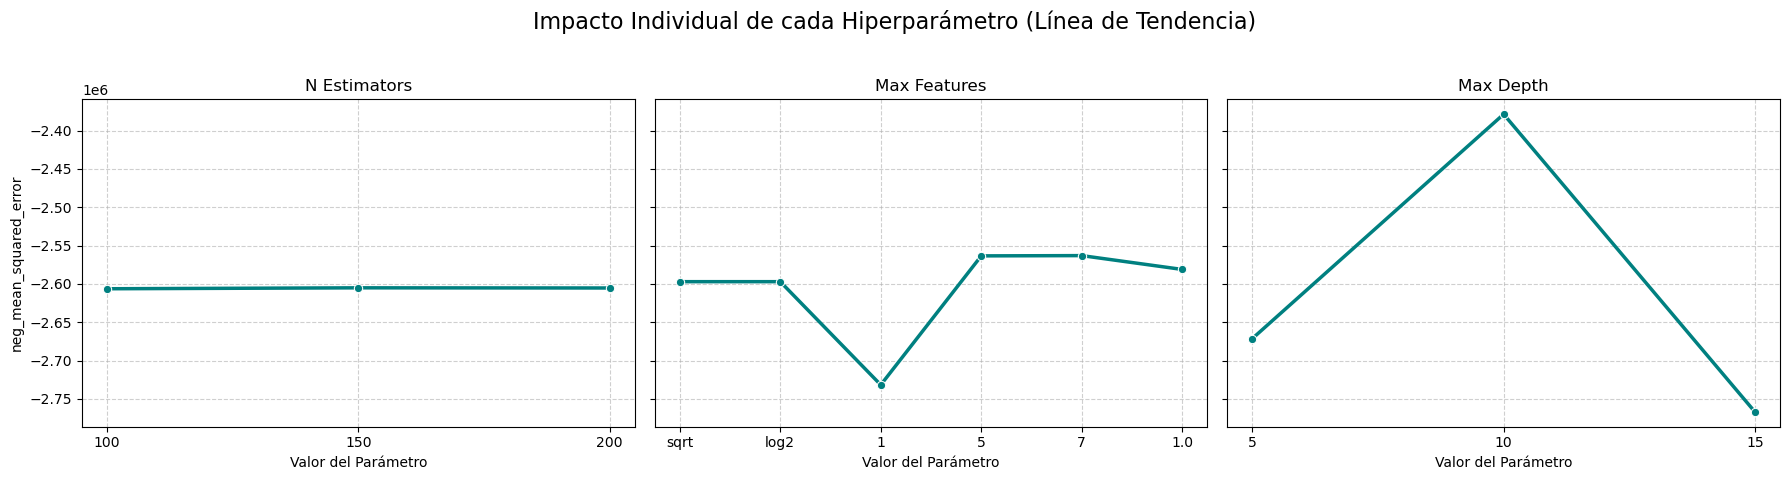

In [39]:
# Celda 5
import seaborn as sns
parametros = {'n_estimators': [100, 150, 200], 'max_features': ['sqrt', 'log2', 1, 5, 7, 1.0],'max_depth': [5, 10, 15]}
clf_random_grid = GridSearchCV(estimator=RandomForestRegressor(random_state=40), param_grid=parametros, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
clf_random_grid.fit(X_train, y_train)

print(f"Mejor combinación: {clf_random_grid.best_params_}")

# Usamos el mejor modelo para predecir
best_rf = clf_random_grid.best_estimator_

y_pred_random_grid = best_rf.predict(X_test)
mae = metrics.mean_absolute_error(y_test, y_pred_random_grid)
mse = metrics.mean_squared_error(y_test, y_pred_random_grid)
rmse = mse**0.5 
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")

res_df = pd.DataFrame(clf_random_grid.cv_results_)

# Convertimos a string para que el eje X sea claro incluso con 'sqrt' o 'log2'
res_df['param_n_estimators'] = res_df['param_n_estimators'].astype(str)
res_df['param_max_features'] = res_df['param_max_features'].astype(str)
res_df['param_max_depth'] = res_df['param_max_depth'].astype(str)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle('Impacto Individual de cada Hiperparámetro (Línea de Tendencia)', fontsize=16)

params = ['param_n_estimators', 'param_max_features', 'param_max_depth']
titulos = ['N Estimators', 'Max Features', 'Max Depth']

for i, param in enumerate(params):
    # sns.lineplot con 'errorbar=None' promedia los resultados y dibuja una sola línea
    sns.lineplot(ax=axes[i], 
                 data=res_df, 
                 x=param, 
                 y='mean_test_score', 
                 marker='o', 
                 linewidth=2.5,
                 color='teal',
                 errorbar=None) # Esto es clave para ver UNA sola línea limpia
    
    axes[i].set_title(titulos[i])
    axes[i].set_xlabel('Valor del Parámetro')
    axes[i].set_ylabel('neg_mean_squared_error' if i == 0 else '')
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Punto 6 - XGBoost con librería

En la celda 6 implementen un modelo XGBoost de regresión con la librería sklearn y comenten sobre el desempeño del modelo.

In [ ]:
# Celda 6
clf = XGBRegressor(random_state=60)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = mse**0.5 
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")

MAE: 1185.227294921875
RMSE: 1605.2354967418332


### Punto 7 - Calibración de parámetros XGBoost

En la celda 7 calibren los parámetros learning rate, gamma y colsample_bytree del modelo XGBoost para regresión, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

In [ ]:
# Celda 7
parametros = {'learning_rate': [0.01, 0.1, 0.2], 'gamma': [0, 0.1, 0.5, 1],'colsample_bytree': [0.5, 0.7, 1.0]}
clf_xgboost_grid = GridSearchCV(estimator=XGBRegressor(random_state=60), param_grid=parametros, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
clf_xgboost_grid.fit(X_train, y_train)

print(f"Mejor combinación: {clf_xgboost_grid.best_params_}")

# Usamos el mejor modelo para predecir
best_xgb = clf_xgboost_grid.best_estimator_

y_pred_random_grid = best_xgb.predict(X_test)
mae = metrics.mean_absolute_error(y_test, y_pred_random_grid)
mse = metrics.mean_squared_error(y_test, y_pred_random_grid)
rmse = mse**0.5 
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")

### Punto 8 - Comparación y análisis de resultados
En la celda 8 comparen los resultados obtenidos de los diferentes modelos (random forest y XGBoost) y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

In [ ]:
# Celda 8
